## Market Mimiking Algorithm
This algorithm is designed to mimik / replay the process of a market. 

Therefore all relevant agents / traders and mechanisms of the market are simulated. 

The idea is that with an increasing number of traders the forecasts by the algorithm gets closer to the price it aims to predict. 

A major goal is to be able to simulate price jumps and explain them with change of trader distribution and offsets (deviations from traders asks and bids from the last transaction price) in the market.

In [56]:
import numpy as np
import pandas as pd
import itertools
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from time import time
import yfinance as yf
from datetime import datetime, timedelta 
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

In [57]:
np.random.seed(42)

---
## Market Mechanism function
Designed to be as close as possible to the actual bids and asks matching function of an exchange.

In [58]:
def simulate_market_ordered_with_aggressor_fixed(bids, asks):
    """
    Simulates market matching using time-priority and correct aggressor-based pricing.
    Each bid/ask is a tuple: (price, volume, index), where index reflects order arrival.
    The later index is the aggressor:
        - If buyer is aggressor: price = ask
        - If seller is aggressor: price = bid
        - If same index: midpoint
    """
    matched_bids = sorted(bids, key=lambda x: x[0], reverse=True)
    matched_asks = sorted(asks, key=lambda x: x[0])

    final_price = None

    while matched_bids and matched_asks:
        bid_price, bid_volume, bid_index = matched_bids[0]
        ask_price, ask_volume, ask_index = matched_asks[0]

        if bid_price >= ask_price:
            traded_volume = min(bid_volume, ask_volume)

            # Determine aggressor correctly
            if bid_index > ask_index:
                transaction_price = ask_price  # buyer aggressor
            elif ask_index > bid_index:
                transaction_price = bid_price  # seller aggressor
            else:
                transaction_price = (bid_price + ask_price) / 2  # tie #can only occur for the cyclical trader at the moment, since the other trading types are mutually exclusive 

            final_price = transaction_price

            # Update volumes
            bid_volume -= traded_volume
            ask_volume -= traded_volume

            if bid_volume == 0:
                matched_bids.pop(0)
            else:
                matched_bids[0] = (bid_price, bid_volume, bid_index)

            if ask_volume == 0:
                matched_asks.pop(0)
            else:
                matched_asks[0] = (ask_price, ask_volume, ask_index)
        else:
            break

    return final_price



## Trading Strategies

The model simulates **six distinct trading behaviors**, each corresponding to a specific strategy:

---

**1. Fundamental Value Traders**

These traders base their decisions on a perceived fundamental value $FV_t$ of the asset.

They follow this trading logic:

- **Buy if**  $P_t < FV_t$ 
- **Sell if** $P_t > FV_t$ 

Here, $P_t$ is the current market price, $FV_t$ is the fundamental value.

> *In future versions, multiple fundamental valuation models (e.g., DCF, multiples) could be integrated.*

---

**2. Cyclical Traders**

These traders have a **structural bias** — either bullish or bearish — independent of current signals. Their decisions are based on an external cycle or trend expectation.

- **Bullish Cyclical Trader:** Buys more frequently
- **Bearish Cyclical Trader:** Sells more frequently

> *These can later be replaced with sentiment models (e.g., language models parsing news or social media sentiment).*

---

**3. Momentum Traders**

Momentum traders rely on recent price movements to guide their decisions.

- **Buy if** $P_{t-2} < P_{t-1}$
- **Sell if** $P_{t-2} > P_{t-1}$

> *They aim to ride the trend.*

---

**4. Moving Average (MA) Traders**

These traders use the difference between short- and long-term moving averages.

- **Buy if** $SMA_{5} > SMA_{10}$
- **Sell if** $SMA_{5} < SMA_{10}$

Where:

- $SMA_5$ = 5-day simple moving average  
- $SMA_{10}$ = 10-day simple moving average

> *They assume trend continuation when the short-term MA crosses above the long-term.*

---

**5. Relative Strength Index (RSI) Traders**

They trade based on the RSI indicator, which identifies **overbought** and **oversold** conditions.

$$rs = \frac{avg \: gain}{avg \: loss}$$
$$RSI = 100 - \frac{100}{1 + rs}$$

- **Buy if** $RSI < 30$ (oversold)
- **Sell if** $RSI > 70$ (overbought)

> *RSI reflects momentum and the magnitude of recent gains vs. losses.*

---

**6. Bollinger Band (BB) Traders**

They trade when prices hit the statistical bands around a moving average.

- **Buy if** $P_t < \text{Lower Band}$
- **Sell if** $P_t > \text{Upper Band}$

Bands are defined as:

- $\text{Upper Band} = SMA_{10} + \sigma$
- $\text{Lower Band} = SMA_{10} - \sigma$

> *They bet on mean reversion after sharp moves.*

---


In [59]:
def calculate_sma(close_list, period=10): 
    if len(close_list) < period:
        return np.nan
    return np.mean(close_list[-period:])

def ma_crossover_signal(short_ma_now, long_ma_now, short_ma_prev, long_ma_prev):
    if np.isnan(short_ma_now) or np.isnan(long_ma_now) or np.isnan(short_ma_prev) or np.isnan(long_ma_prev):
        return None
    if short_ma_prev < long_ma_prev and short_ma_now > long_ma_now:
        return 'BUY'
    elif short_ma_prev > long_ma_prev and short_ma_now < long_ma_now:
        return 'SELL'
    return None


In [60]:
def calculate_rsi_from_list(close_list, period=10):  
    if len(close_list) < period + 1:
        return np.nan
    deltas = np.diff(close_list[-(period + 1):])
    gains = np.where(deltas > 0, deltas, 0)
    losses = np.where(deltas < 0, -deltas, 0)
    avg_gain = np.mean(gains)
    avg_loss = np.mean(losses)
    if avg_loss == 0:
        return 100
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def rsi_signal(rsi, position_open):
    if rsi < 30 and not position_open:
        return 'BUY'
    elif rsi > 70 and position_open:
        return 'SELL'
    return None


In [61]:
def calculate_bollinger_from_list(close_list, period=10, std_dev=1):
    if len(close_list) < period:
        return (np.nan, np.nan)
    window = close_list[-period:]
    sma = np.mean(window)
    std = np.std(window)
    upper_band = sma + std_dev * std
    lower_band = sma - std_dev * std
    return (upper_band, lower_band)
    
def bollinger_signal(price, lower_band, upper_band, position_open):
    if price < lower_band:
        return 'BUY'
    elif price > upper_band:
        return 'SELL'
    return None


In [62]:
def generate_market_orders(sim_close, sim_prev, sim_vol, weights, fv, bid_ask_offsets, rolling_closes):
    (
        fund_bid, fund_ask, cyc_bid, cyc_ask,
        mom_bid, mom_ask, ma_bid, ma_ask,
        rsi_bid, rsi_ask, bb_bid, bb_ask
    ) = bid_ask_offsets
    w_fund, w_cyc, w_mom, w_ma, w_rsi, w_bb = weights

    bid_prices, ask_prices = [], []

    if sim_close < fv:
        bid_prices.append((sim_close + fund_bid, w_fund * sim_vol, 0))
    if sim_close > fv:
        ask_prices.append((sim_close - fund_ask, w_fund * sim_vol, 0))

    bid_prices.append((sim_close + cyc_bid, w_cyc * sim_vol, 1))
    ask_prices.append((sim_close - cyc_ask, w_cyc * sim_vol, 1))

    if sim_prev < sim_close:
        bid_prices.append((sim_close + mom_bid, w_mom * sim_vol, 2))
    if sim_prev > sim_close:
        ask_prices.append((sim_close - mom_ask, w_mom * sim_vol, 2))

    sma5 = calculate_sma(rolling_closes, 5)
    sma10 = calculate_sma(rolling_closes, 10)
    prev_sma5 = calculate_sma(rolling_closes[:-1], 5)
    prev_sma10 = calculate_sma(rolling_closes[:-1], 10)
    rsi = calculate_rsi_from_list(rolling_closes)
    bb_upper, bb_lower = calculate_bollinger_from_list(rolling_closes, 10, 1)

    signal_ma = ma_crossover_signal(sma5, sma10, prev_sma5, prev_sma10)
    if signal_ma == 'BUY':
        bid_prices.append((sim_close + ma_bid, w_ma * sim_vol, 3))
    elif signal_ma == 'SELL':
        ask_prices.append((sim_close - ma_ask, w_ma * sim_vol, 3))

    signal_rsi = rsi_signal(rsi, False)
    if signal_rsi == 'BUY':
        bid_prices.append((sim_close + rsi_bid, w_rsi * sim_vol, 4))
    elif signal_rsi == 'SELL':
        ask_prices.append((sim_close - rsi_ask, w_rsi * sim_vol, 4))

    signal_bb = bollinger_signal(sim_close, bb_lower, bb_upper, False)
    if signal_bb == 'BUY':
        bid_prices.append((sim_close + bb_bid, w_bb * sim_vol, 5))
    elif signal_bb == 'SELL':
        ask_prices.append((sim_close - bb_ask, w_bb * sim_vol, 5))

    return bid_prices, ask_prices


---
## Find Best Trader Distribution and Offsets
As mentioned in the description, one of the main contributions of this algorithm is to find the distribution of trading types, which will help in **simulating the price movements** and also to deliver an **explanation for price jumps**. 

Bid and ask offsets are the additions to the closing price from the different trading types, depending on ask or bid.
The following objective is to improve forecasting accuracy by dynamically finding weights of trading types and their respective bid and ask offsets at the forecasting start.

In [63]:
bid_ask_offsets = [
            0.057, 1.261,  # Fundamental
            0.335, 0.555,  # Cyclical
            0.74, 0.417,  # Momentum
            1.843, 0.702,  # MA
            1.247, 1.315,  # RSI
            2.406, 0.443,  # BB
        ]

In [64]:
def simulate_price_from_weights_and_offsets(
    weights, sim_close, sim_prev, sim_vol, fv, bid_ask_offsets, rolling_closes
):
    """
    Simulates the next price based on trader type weights and bid/ask offsets.

    Parameters:
    - weights: List of 6 floats (one per trader type)
    - sim_close: Last simulated close price
    - sim_prev: Previous simulated price (t-1)
    - sim_vol: Volume for simulation
    - fv: Fundamental value
    - bid_ask_offsets: Flat list of 12 offsets (6 bid + 6 ask)
    - rolling_closes: History for indicators

    Returns:
    - Simulated price (float)
    """
    
    bid_prices, ask_prices = generate_market_orders(
        sim_close=sim_close,
        sim_prev=sim_prev,
        sim_vol=sim_vol,
        weights=weights,
        fv=fv,
        bid_ask_offsets=bid_ask_offsets,  # already flat
        rolling_closes=rolling_closes
    )

    valid_bids = [(p, v, t) for p, v, t in bid_prices if p is not None and v > 0]
    valid_asks = [(p, v, t) for p, v, t in ask_prices if p is not None and v > 0]

    return simulate_market_ordered_with_aggressor_fixed(valid_bids, valid_asks)


In [65]:
def joint_objective(params, sim_close, sim_prev, sim_vol, real_close_today, fv, rolling_closes):
    weights = np.array(params[:6])
    offsets = np.array(params[6:])
    weights /= weights.sum()

    # Simulate forward
    for _ in range(5):
        sim_close = simulate_price_from_weights_and_offsets(
            weights, sim_close, sim_prev, sim_vol, fv, offsets, rolling_closes
        ) or sim_close
        sim_prev = sim_close
        sim_vol = max(1, sim_vol)# + np.random.randint(-50, 50))

    # regularization term to avoid mainly offset tuning 
    offset_penalty = 0.3 * np.linalg.norm(offsets)  

    return (sim_close - real_close_today) ** 2 + offset_penalty


$$\text{np.linalg.norm(offsets)}$$

This computes the **L2 norm** (Euclidean norm) of the `offsets` vector:

$$
\text{L2 norm} = \sqrt{\sum_{i=1}^{12} \text{offset}_i^2}
$$

It measures the overall "magnitude" or "length" of the 12-dimensional offset vector (6 bid offsets + 6 ask offsets). 

Larger values imply more aggressive tuning of offsets, while smaller values imply more conservative, stable offsets. This term is used to **penalize large offset values** and discourage overfitting via offset manipulation and **encourage changing of weights for forecast accuracy improvement.**


In [66]:
def find_best_distribution_and_offsets(
    past_anchor_points, real_close_today, fv, rolling_closes, avg_low_offset, avg_high_offset
):
    """
    Finds optimal trader weights and bid/ask offsets to match today's real close
    using a simulation path from a previous anchor (t-6).
    """
    # Retrieve base simulation input from last anchor
    base_close, base_second, forecast_volume = past_anchor_points[-1]

    # Initial guess: uniform weights and 0.1 for each offset
    initial_weights = np.array([1 / 6] * 6)
    initial_offsets = np.array([0.1] * 12)
    initial_guess = np.concatenate([initial_weights, initial_offsets])

    # Bounds
    bounds = [(0, 1)] * 6 + [(avg_low_offset, avg_high_offset)] * 12

    result = minimize(
        joint_objective,
        initial_guess,
        args=(base_close, base_second, forecast_volume, real_close_today, fv, rolling_closes),
        bounds=bounds,
        method='L-BFGS-B'
    )

    best_params = result.x
    best_weights = best_params[:6]
    best_weights /= best_weights.sum()
    best_offsets = best_params[6:]

    # Simulate once more using best parameters for visualization or return
    sim_close = base_close
    sim_prev = base_second
    sim_vol = forecast_volume

    for _ in range(5):
        sim_close = simulate_price_from_weights_and_offsets(
            best_weights, sim_close, sim_prev, sim_vol, fv, best_offsets, rolling_closes
        ) or sim_close
        sim_prev = sim_close
        sim_vol = max(1, sim_vol)# + np.random.randint(-50, 50))

    return best_weights, best_offsets, sim_close


The Target variable is the closing price in 5 days and bids and asked from trading types as well as their weights are adjusted to make the 5 days forecast as close as possible to the Target variable, since trading decisions are dependant on the 5 days forecast 
The loss function is defined as:

$$\text{Loss} = (\text{Closing Price in 5 Days} - \text{5 Days Forecast})^2$$

---
## Loop with Trading Strategy
The aim of this nested loop is to produce forecast based on a derived trading type distribution and offsets with the find_best_distribution_and_offsets function at anchor point t=0, 6, 12, etc., and buy / sell (all capital / all shares) when the forecast is above / below the actual price at the anchor point: 

$$Forecast_{t=5} > Close \: price_{t=0} --> buy$$
$$Forecast_{t=5} < Close \: price_{t=0} --> sell$$

The offsets and weights are tuned jointly within the last 5 trading days at each anchor point (t=0, 6, 12, ...), then for the following 5 days the found weights and offsets are played through with the newest simulated price always integrated in the next one to simulate the price movements, triggerning potential trading strategies that will bid and ask with their found distribution and respective offsets. 

<a href="https://ibb.co/Y7yZw5ch"><img src="https://i.ibb.co/7JR4L3nK/Chat-GPT-Image-15-Apr-2025-11-19-16.png" alt="Chat-GPT-Image-15-Apr-2025-11-19-16" border="0"></a>

This diagram should just illustrate how the forecasting works appoximately. It doesn't fully reflect the complexity of the algorithm including timing of simulation start, offset tuning, etc..

In [67]:
def run_trading_strategy(data, fv, capital=10000, shares=0):
    results = []

    # Initialize rolling close list with at least 2 values for MA, RSI, etc.
    rolling_closes = list(data['Close'].iloc[:2])
    last_close = float(rolling_closes[-1])

    # Initial trader weights and bid/ask offsets
    last_weights = [0.2608, 0.2987, 0.1002, 0.1623, 0.071, 0.107]
    last_offsets = [0.1] * 12

    # For storing simulation outputs
    forecast_sim_prices_dict = {}
    anchor_forecast_targets = {}
    forecast_anchor = None

    for i in range(6, len(data)):  # Start at 6 so we always have 5 prior days
        date = data.index[i]
        real_close = float(data['Close'].iloc[i])
        daily_volume = float(data['Volume'].iloc[i])
        shocked_volume = max(1, int(daily_volume))  # Optional volume noise

        is_anchor = False
        action = "HOLD"

        # Every 6th day: anchor point and re-optimize strategy
        if i % 6 == 0:
            is_anchor = True
            # Ensure forecast_anchor is always float
            forecast_anchor = float(real_close) if not isinstance(real_close, list) else float(real_close[0])

            # Use last two real closes for simulation starting points
            base_close = float(data['Close'].iloc[i - 1])
            base_second = float(data['Close'].iloc[i - 2])
            forecast_volume = float(data['Volume'].iloc[i - 1])

            # Calculate bid/ask offset bounds from past 5 days
            recent = data.iloc[i - 5:i]
            avg_low_offset = (recent['Low'] - recent['Close'].shift(1)).dropna().mean()
            avg_high_offset = (recent['High'] - recent['Close'].shift(1)).dropna().mean()

            # Setup previous anchor simulation conditions
            past_anchor_points = [(base_close, base_second, forecast_volume)]

            # Optimize weights and offsets to best hit today's close
            last_weights, last_offsets, _ = find_best_distribution_and_offsets(
                past_anchor_points,
                real_close,
                fv,
                rolling_closes,
                avg_low_offset,
                avg_high_offset
            )

            # Forecast next 5 days using newly fitted strategy
            sim_close = base_close
            sim_prev = base_second
            sim_vol = forecast_volume
            forecast_sim_prices = []

            for j in range(5):
                sim_close = simulate_price_from_weights_and_offsets(
                    last_weights, sim_close, sim_prev, sim_vol, fv, last_offsets, rolling_closes
                ) or sim_close
                sim_prev = sim_close
                sim_vol = max(1, sim_vol)# + np.random.randint(-50, 50))
                forecast_sim_prices.append(sim_close)

                if i + j + 1 < len(data):
                    forecast_sim_prices_dict[i + j + 1] = float(sim_close)  # Ensure scalar

            # Save for plotting or analysis
            anchor_forecast_targets[i] = (forecast_anchor, forecast_sim_prices[-1])

            # Final safety for forecast_anchor
            forecast_anchor = float(forecast_anchor) if isinstance(forecast_anchor, list) else forecast_anchor

            # Trade logic: compare target to today's close
            trade_size = int(capital // forecast_anchor)
            if forecast_sim_prices[-1] > forecast_anchor and trade_size > 0 :
                capital -= trade_size * forecast_anchor
                shares += trade_size
                action = "BUY"
            elif forecast_sim_prices[-1] < forecast_anchor and shares > 0:
                capital += shares * forecast_anchor
                shares = 0
                action = "SELL"

        # Use the forecast if available, else fallback to last close
        sim_close = forecast_sim_prices_dict.get(i, last_close)

        # Log simulation output
        results.append({
            'Date': date,
            'Real Close': real_close,
            'Simulated Close': sim_close,
            'Action': action,
            'Capital': capital,
            'Shares': shares,
            'Portfolio Value': capital + shares * real_close,
            'Forecast Anchor Used': forecast_anchor if is_anchor else None,
            'Best Distribution': last_weights if is_anchor else None,
            'Is Anchor': is_anchor,
            'Weight Fundamental': last_weights[0],
            'Weight Cyclical': last_weights[1],
            'Weight Momentum': last_weights[2],
            'Weight MA': last_weights[3],
            'Weight RSI': last_weights[4],
            'Weight BB': last_weights[5]
        })

        rolling_closes.append(real_close)
        last_close = real_close

    return pd.DataFrame(results)


---
## Usage example

In [68]:
ticker_symbol = 'HPQ'
today = datetime.now().strftime('%Y-%m-%d')
yesterday = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

historical_data = yf.download(ticker_symbol, start='2020-01-01', end='2024-01-01', multi_level_index=False)

if historical_data.empty or len(historical_data) < 3:
    raise ValueError("Not enough data to run simulation.")

ticker = yf.Ticker(ticker_symbol)
fv = ticker.analyst_price_targets['mean']
print(f"Analyst Mean Price Target (Fundamental Value): {fv}")

[*********************100%***********************]  1 of 1 completed

Analyst Mean Price Target (Fundamental Value): 33.62133


---
## Execution

In [69]:
simulation_results = run_trading_strategy(historical_data, fv)
simulation_results.set_index('Date', inplace=True)
df = simulation_results
df

,Real Close,Simulated Close,Action,Capital,Shares,Portfolio Value,Forecast Anchor Used,Best Distribution,Is Anchor,Weight Fundamental,Weight Cyclical,Weight Momentum,Weight MA,Weight RSI,Weight BB
Date,,,,,,,,,,,,,,,
2020-01-10,17.979082,17.264294,HOLD,10000.000000,0,10000.000000,17.979082,"[0.13912911486918425, 0.30435442565407866, 0.1...",True,0.139129,0.304354,0.139129,0.139129,0.139129,0.139129
2020-01-13,18.046358,17.876410,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.139129,0.304354,0.139129,0.139129,0.139129,0.139129
2020-01-14,17.995901,17.891470,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.139129,0.304354,0.139129,0.139129,0.139129,0.139129
2020-01-15,18.012716,17.906530,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.139129,0.304354,0.139129,0.139129,0.139129,0.139129
2020-01-16,18.222950,17.921591,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.139129,0.304354,0.139129,0.139129,0.139129,0.139129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,28.899727,29.517913,HOLD,18.665908,436,12618.946822,NaN,None,False,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2023-12-26,29.119970,28.899727,SELL,12714.972968,0,12714.972968,29.119970,"[0.166795975273552, 0.166795975273552, 0.16679...",True,0.166796,0.166796,0.166796,0.166020,0.166796,0.166796
2023-12-27,28.957182,28.940552,HOLD,12714.972968,0,12714.972968,NaN,None,False,0.166796,0.166796,0.166796,0.166020,0.166796,0.166796


---
## Plotting

In [70]:
def plot_segmented_simulation(df, fv):
    
    plt.figure(figsize=(14, 7))

    # Plot the real close price
    plt.plot(df.index, df['Real Close'], label='Real Close', linewidth=2, color='tab:blue')

    # Segment the simulated close to break connections across forecast horizons
    segments = []
    i = 1
    while i < len(df):
        if df['Is Anchor'].iloc[i - 1]:
            segment = []
            for j in range(5):
                idx = i + j
                if idx < len(df) and not df['Is Anchor'].iloc[idx]:
                    segment.append((df.index[idx], df['Simulated Close'].iloc[idx]))
            if segment:
                segments.append(segment)
            i += 5  # Skip over the forecast period
        else:
            i += 1

    # Plot each simulated segment separately
    for segment in segments:
        dates, values = zip(*segment)
        plt.plot(dates, values, linestyle='--', color='tab:orange',
                 label='Simulated Close' if segment == segments[0] else "")

    # Forecast anchor markers (vertical lines)
    anchors = df[df['Is Anchor']]
    for idx in anchors.index:
        plt.axvline(idx, color='orange', linestyle='--', alpha=0.4,
                    label='Forecast Horizon' if idx == anchors.index[0] else "")

    # Buy/Sell signals only at anchor points
    buy_signals = df[(df['Action'] == 'BUY') & (df['Is Anchor'])]
    sell_signals = df[(df['Action'] == 'SELL') & (df['Is Anchor'])]
    plt.scatter(buy_signals.index, buy_signals['Real Close'], marker='^',
                color='green', s=100, label='Buy Signal')
    plt.scatter(sell_signals.index, sell_signals['Real Close'], marker='v',
                color='red', s=100, label='Sell Signal')

    plt.title("Real vs Segmented Simulated Close with Forecast Anchors and Trade Signals")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


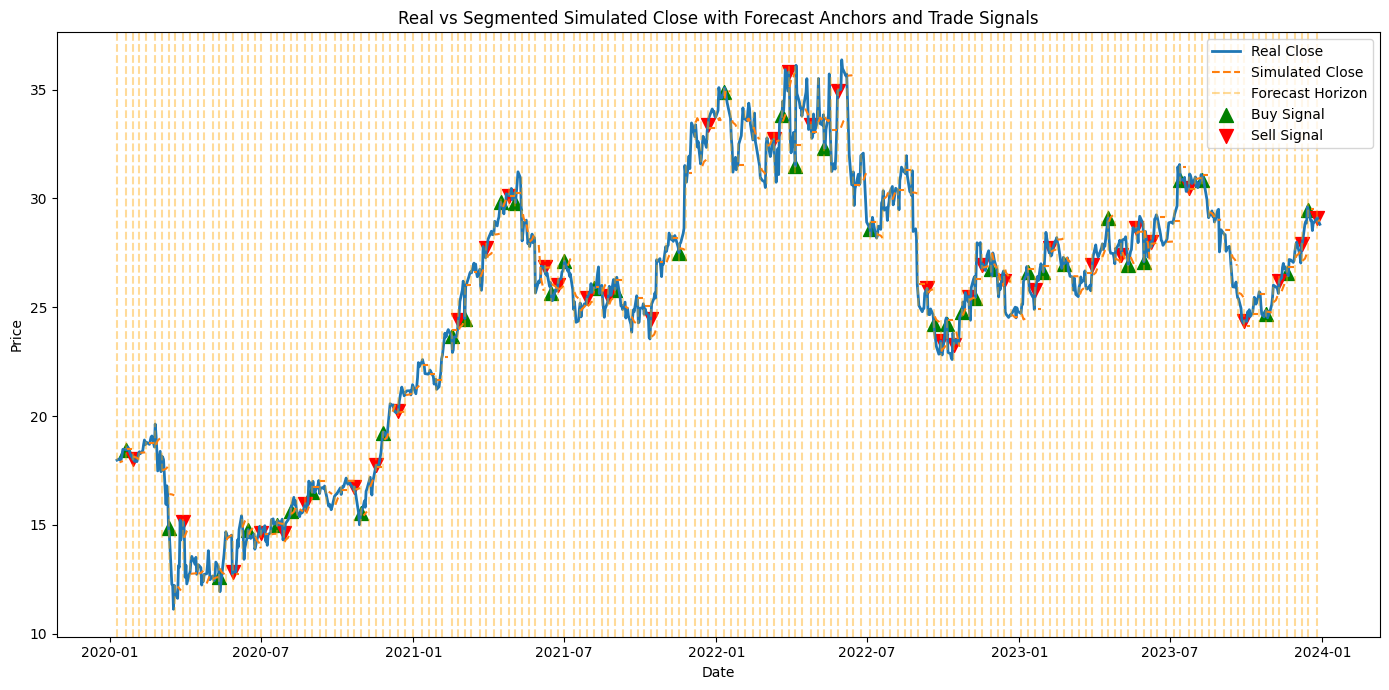

In [71]:
plot_segmented_simulation(simulation_results, fv)

In [72]:
def plot_segmented_simulation_with_weights(df, fv):
    
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot real close price
    ax1.plot(df.index, df['Real Close'], label='Real Close', linewidth=2, color='tab:blue')

    # Forecast segments: only plot t=1 to t=5 after each anchor (i.e., 5 forecasted points max)
    segments = []
    i = 1
    while i < len(df):
        if df['Is Anchor'].iloc[i - 1]:
            segment = []
            for j in range(5):
                idx = i + j
                if idx < len(df) and not df['Is Anchor'].iloc[idx]:
                    segment.append((df.index[idx], df['Simulated Close'].iloc[idx]))
            if segment:
                segments.append(segment)
            i += 5  # Skip over the forecast period
        else:
            i += 1

    # Plot each simulated segment separately
    for segment in segments:
        dates, values = zip(*segment)
        ax1.plot(dates, values, linestyle='--', color='tab:orange',
                 label='Simulated Close' if segment == segments[0] else "")

    # Forecast anchor markers
    anchors = df[df['Is Anchor']]
    for idx in anchors.index:
        ax1.axvline(idx, color='orange', linestyle='--', alpha=0.4,
                    label='Forecast Horizon' if idx == anchors.index[0] else "")

    # Buy/Sell signals at anchor points
    buy_signals = df[(df['Action'] == 'BUY') & (df['Is Anchor'])]
    sell_signals = df[(df['Action'] == 'SELL') & (df['Is Anchor'])]
    ax1.scatter(buy_signals.index, buy_signals['Real Close'], marker='^',
                color='green', s=100, label='Buy Signal')
    ax1.scatter(sell_signals.index, sell_signals['Real Close'], marker='v',
                color='red', s=100, label='Sell Signal')

    ax1.set_ylabel("Price")
    ax1.set_title("Real vs Segmented Simulated Close with Forecast Anchors and Trade Signals")
    ax1.grid(False)

    # Second y-axis for trader weights
    ax2 = ax1.twinx()
    weight_cols = [
        'Weight Fundamental', 'Weight Cyclical', 'Weight Momentum',
        'Weight MA', 'Weight RSI', 'Weight BB'
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']
    bottom = np.zeros(len(df))

    for col, color in zip(weight_cols, colors):
        ax2.bar(df.index, df[col], bottom=bottom, width=1.0, color=color, alpha=0.2, label=col)
        bottom += df[col].values

    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Trader Type Weights")

    # Combine and clean legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc='lower left', bbox_to_anchor=(0, -0.3), ncol=3)

    fig.tight_layout()
    plt.show()


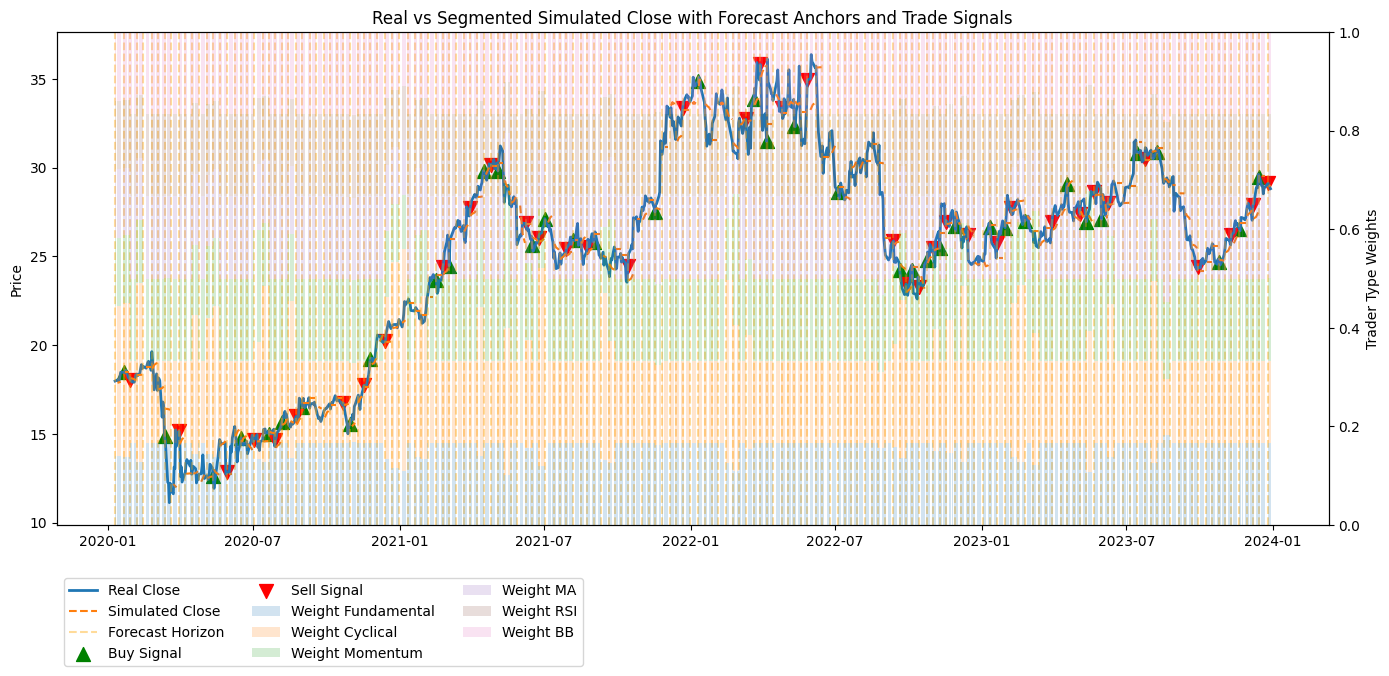

In [73]:
plot_segmented_simulation_with_weights(simulation_results, fv)

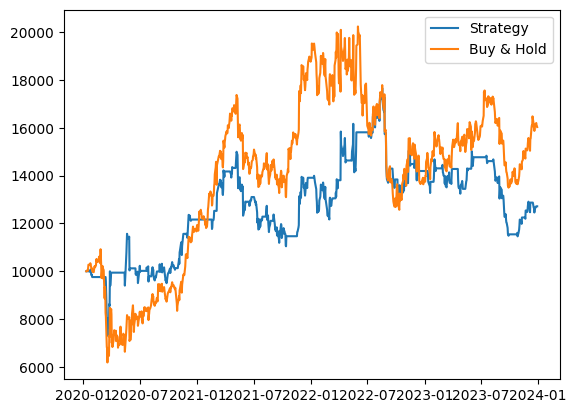

In [74]:
plt.plot(simulation_results.index, simulation_results['Portfolio Value'], label='Strategy', )
buy_and_hold_value = simulation_results['Real Close'] / simulation_results['Real Close'].iloc[0] * 10000
plt.plot(simulation_results.index, buy_and_hold_value, label='Buy & Hold')
plt.legend()

## Performance measures

In [75]:
# Define performance metrics functions
def calculate_cumulative_return(portfolio_values):
    return (portfolio_values.iloc[-1] - portfolio_values.iloc[0]) / portfolio_values.iloc[0]

def calculate_cagr(portfolio_values, dates):
    V0 = portfolio_values.iloc[0]
    Vt = portfolio_values.iloc[-1]
    days = (dates[-1] - dates[0]).days
    yfrac = days / 252  # uses 252 trading days approximation
    return (Vt / V0) ** (1 / yfrac) - 1

def calculate_sharpe_ratio(returns):
    sharpe_ratio = returns.mean() / returns.std()
    ann_sharpe_ratio = sharpe_ratio * np.sqrt(252)
    return ann_sharpe_ratio

def calculate_sortino_ratio(returns):
    downside_std = returns[returns < 0].std()
    sortino_ratio = returns.mean() / downside_std
    ann_sortino_ratio = sortino_ratio * np.sqrt(252)
    return ann_sortino_ratio

def max_drawdown(return_series):
    comp_ret = (return_series + 1).cumprod()
    peak = comp_ret.expanding(min_periods=1).max()
    dd = (comp_ret / peak) - 1
    return dd.min()

# Compute returns
df['Portfolio Value'] = simulation_results['Portfolio Value']
df['Returns'] = df['Portfolio Value'].pct_change().dropna()

# Buy & Hold Value
df['Buy and Hold Value'] = simulation_results['Real Close'] / simulation_results['Real Close'].iloc[0] * 10000
df['Buy and Hold Returns'] = df['Buy and Hold Value'].pct_change().dropna()

# Calculate metrics
strategy_cum_return = calculate_cumulative_return(df['Portfolio Value'])
strategy_cagr = calculate_cagr(df['Portfolio Value'], df.index)
strategy_sharpe = calculate_sharpe_ratio(df['Returns'].dropna())
strategy_sortino = calculate_sortino_ratio(df['Returns'].dropna())
strategy_max_dd = max_drawdown(df['Returns'].dropna())

buyhold_cum_return = calculate_cumulative_return(df['Buy and Hold Value'])
buyhold_cagr = calculate_cagr(df['Buy and Hold Value'], df.index)
buyhold_sharpe = calculate_sharpe_ratio(df['Buy and Hold Returns'].dropna())
buyhold_sortino = calculate_sortino_ratio(df['Buy and Hold Returns'].dropna())
buyhold_max_dd = max_drawdown(df['Buy and Hold Returns'].dropna())

# Create summary table
performance_df = pd.DataFrame({
    'Metric': [
        'Cumulative Return', 'CAGR (Annual Growth Rate)',
        'Sharpe Ratio (Ann.)', 'Sortino Ratio (Ann.)', 'Max Drawdown'
    ],
    'Strategy': [
        f"{strategy_cum_return:.2%}", f"{strategy_cagr:.2%}",
        f"{strategy_sharpe:.2f}", f"{strategy_sortino:.2f}", f"{strategy_max_dd:.2%}"
    ],
    'Buy & Hold': [
        f"{buyhold_cum_return:.2%}", f"{buyhold_cagr:.2%}",
        f"{buyhold_sharpe:.2f}", f"{buyhold_sortino:.2f}", f"{buyhold_max_dd:.2%}"
    ]
})

print(performance_df)


                      Metric Strategy Buy & Hold
0          Cumulative Return   27.15%     60.26%
1  CAGR (Annual Growth Rate)    4.27%      8.55%
2        Sharpe Ratio (Ann.)     0.35       0.50
3       Sortino Ratio (Ann.)     0.36       0.65
4               Max Drawdown  -35.09%    -43.33%


---
## Closer examination of forecasting mechanism 
Originally this was the out of sample test data set, however, since the new mechanism of the algorithm tunes bid and asks offsets within the last 5 trading days iteratively, the classical split of training and test data isn't necessary anymore. The last year of the data can still be used to examine the forecasting mechganism closer.

In [76]:
ticker_symbol = 'HPQ'
today = datetime.now().strftime('%Y-%m-%d')
yesterday = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

historical_data = yf.download(ticker_symbol, start='2024-01-01', end='2025-01-01' , multi_level_index=False)

if historical_data.empty or len(historical_data) < 3:
    raise ValueError("Not enough data to run simulation.")

ticker = yf.Ticker(ticker_symbol)
fv = ticker.analyst_price_targets['mean']
print(f"Analyst Mean Price Target (Fundamental Value): {fv}")

[*********************100%***********************]  1 of 1 completed

Analyst Mean Price Target (Fundamental Value): 33.62133


In [77]:
simulation_results = run_trading_strategy(historical_data, fv)
simulation_results.set_index('Date', inplace=True)
df = simulation_results
df

,Real Close,Simulated Close,Action,Capital,Shares,Portfolio Value,Forecast Anchor Used,Best Distribution,Is Anchor,Weight Fundamental,Weight Cyclical,Weight Momentum,Weight MA,Weight RSI,Weight BB
Date,,,,,,,,,,,,,,,
2024-01-10,29.052940,28.631605,HOLD,10000.000000,0,10000.000000,29.05294,"[0.14459161559994257, 0.27704192200028716, 0.1...",True,0.144592,0.277042,0.144592,0.144592,0.144592,0.144592
2024-01-11,28.727362,28.906563,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.144592,0.277042,0.144592,0.144592,0.144592,0.144592
2024-01-12,28.545424,28.932551,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.144592,0.277042,0.144592,0.144592,0.144592,0.144592
2024-01-16,27.855967,28.958538,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.144592,0.277042,0.144592,0.144592,0.144592,0.144592
2024-01-17,27.434631,28.984526,HOLD,10000.000000,0,10000.000000,NaN,None,False,0.144592,0.277042,0.144592,0.144592,0.144592,0.144592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,33.102325,32.507376,HOLD,31.385227,347,11517.892155,NaN,None,False,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2024-12-26,33.092430,32.607376,HOLD,31.385227,347,11514.458477,NaN,None,False,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2024-12-27,32.943943,32.707375,HOLD,31.385227,347,11462.933456,NaN,None,False,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


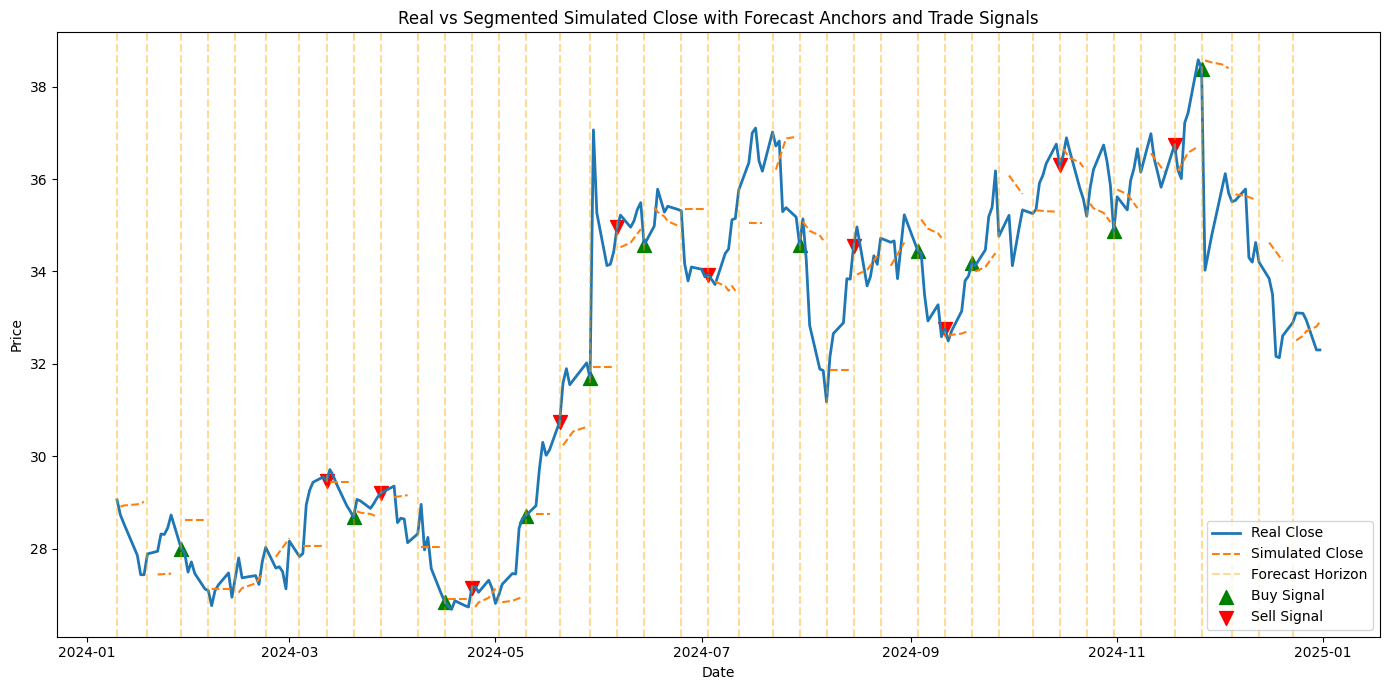

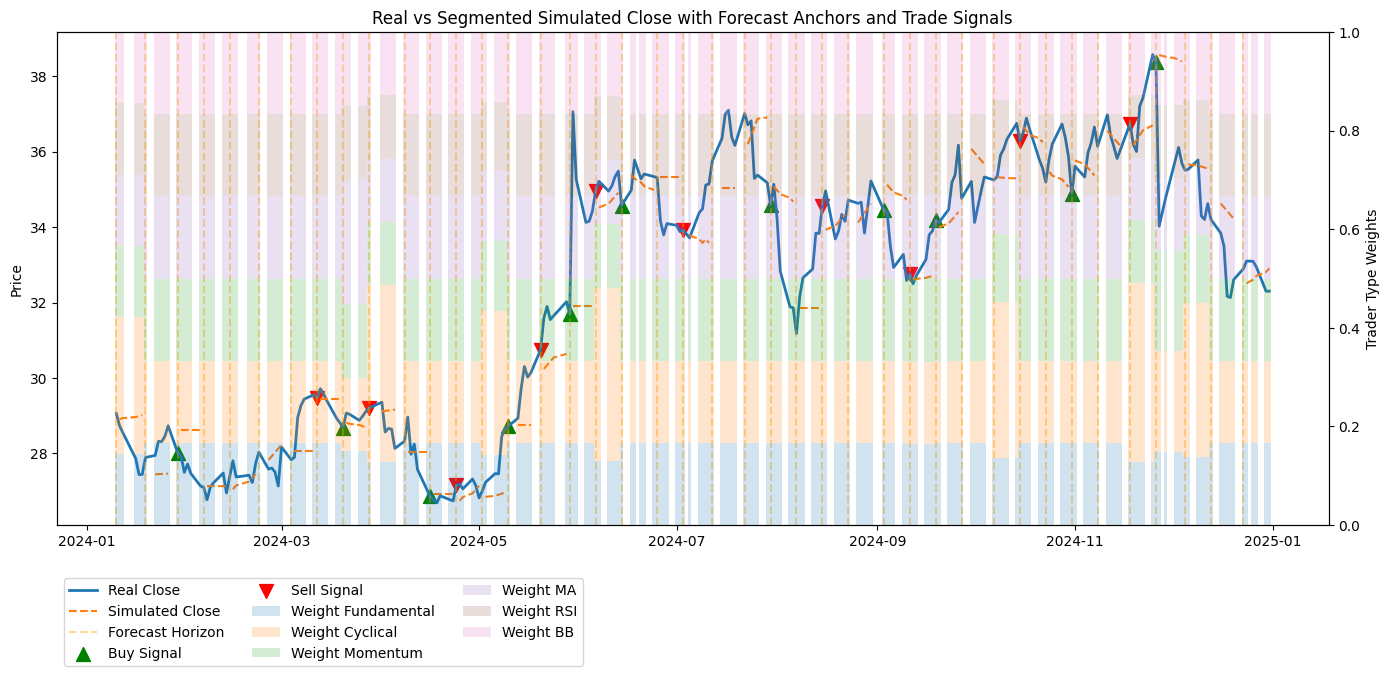

In [78]:
plot_segmented_simulation(simulation_results, fv)
plot_segmented_simulation_with_weights(simulation_results, fv)

<a href="https://ibb.co/xtCf5HRQ"><img src="https://i.ibb.co/FLx07Vjt/Forecasting-mechanism.jpg" alt="Forecasting-mechanism" border="0"></a>

This diagram should just show a bit how the found weights influence the forecasting and trade decisions. It doesn't fully reflect the complexity of the algorithm including offset tuning, etc..

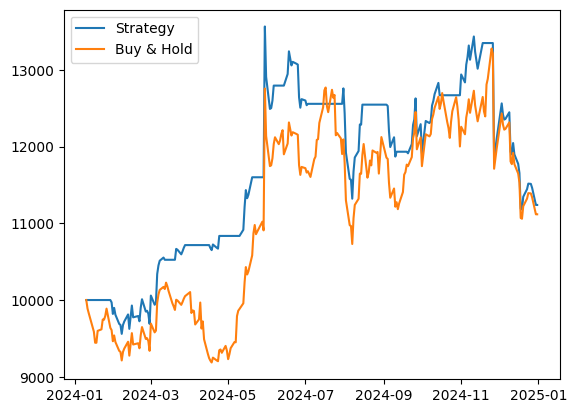

In [79]:
plt.plot(simulation_results.index, simulation_results['Portfolio Value'], label='Strategy')
buy_and_hold_value = simulation_results['Real Close'] / simulation_results['Real Close'].iloc[0] * 10000
plt.plot(simulation_results.index, buy_and_hold_value, label='Buy & Hold')
plt.legend()

In [80]:
# Compute returns
df['Portfolio Value'] = simulation_results['Portfolio Value']
df['Returns'] = df['Portfolio Value'].pct_change().dropna()

# Buy & Hold Value
df['Buy and Hold Value'] = simulation_results['Real Close'] / simulation_results['Real Close'].iloc[0] * 10000
df['Buy and Hold Returns'] = df['Buy and Hold Value'].pct_change().dropna()

# Calculate metrics
strategy_cum_return = calculate_cumulative_return(df['Portfolio Value'])
strategy_cagr = calculate_cagr(df['Portfolio Value'], df.index)
strategy_sharpe = calculate_sharpe_ratio(df['Returns'].dropna())
strategy_sortino = calculate_sortino_ratio(df['Returns'].dropna())
strategy_max_dd = max_drawdown(df['Returns'].dropna())

buyhold_cum_return = calculate_cumulative_return(df['Buy and Hold Value'])
buyhold_cagr = calculate_cagr(df['Buy and Hold Value'], df.index)
buyhold_sharpe = calculate_sharpe_ratio(df['Buy and Hold Returns'].dropna())
buyhold_sortino = calculate_sortino_ratio(df['Buy and Hold Returns'].dropna())
buyhold_max_dd = max_drawdown(df['Buy and Hold Returns'].dropna())

# Create summary table
performance_df = pd.DataFrame({
    'Metric': [
        'Cumulative Return', 'CAGR (Annual Growth Rate)',
        'Sharpe Ratio (Ann.)', 'Sortino Ratio (Ann.)', 'Max Drawdown'
    ],
    'Strategy': [
        f"{strategy_cum_return:.2%}", f"{strategy_cagr:.2%}",
        f"{strategy_sharpe:.2f}", f"{strategy_sortino:.2f}", f"{strategy_max_dd:.2%}"
    ],
    'Buy & Hold': [
        f"{buyhold_cum_return:.2%}", f"{buyhold_cagr:.2%}",
        f"{buyhold_sharpe:.2f}", f"{buyhold_sortino:.2f}", f"{buyhold_max_dd:.2%}"
    ]
})

print(performance_df)


                      Metric Strategy Buy & Hold
0          Cumulative Return   12.40%     11.18%
1  CAGR (Annual Growth Rate)    8.62%      7.79%
2        Sharpe Ratio (Ann.)     0.56       0.49
3       Sortino Ratio (Ann.)     0.57       0.69
4               Max Drawdown  -17.58%    -16.72%


**Performance of the strategy is not good momentarily. But the main intent here is to make the infrastructure running. If the infrastructure runs as intended, the performance should increase with the inclusion of more trading types.** 

**I could have chosen an asset and a period where the strategy outperformed the buy and hold strategy, however for me, it was important to show the third to last chart as it is. Because it shows that the algorithm can forecast price deviations as hoped, without relying on randomness, which for me was a first success of this prototype.**

Here I still explain the performance measures to fulfill the assignment's requirement: 

### Backtesting Performance Analysis

---

#### **1. Cumulative Return**

**Formula:**

$$
\text{Cumulative Return} = \frac{V_{\text{end}} - V_{\text{start}}}{V_{\text{start}}} \times 100
$$

**Interpretation:**  
- **Strategy:** 12.40%      
- **Buy & Hold:** +11.18%

  → The trading strategy performed slightly better than the Buy and hold, although no transaction costs were taken into account

---

#### **2. Sharpe Ratio (Annualized)**

**Formula:**

$$
\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}
$$

Where:  
- $R_p$: portfolio return  
- $R_f$: risk-free rate  (0 in this case)
- $\sigma_p$: standard deviation of portfolio return

**Interpretation:**  
- **Strategy:** 0.56   
- **Buy & Hold:** 0.49

  → Also in terms of return relative to risk, the strategy slightly outperforms.

---

### 3. Max Drawdown

**Definition:**  
Max drawdown quantifies the steepest decline from peak to trough observed for an investment during a specific period. Unlike ratios like Sharpe or Sortino, it does not assume normally distributed returns.

This metric is crucial for assessing **risk of large cumulative losses**—especially in cases where returns might exhibit **clustering or non-independence**.


**Formula:**

$$
\text{Max Drawdown} = \max_{t \in [0, T]} \left( \frac{\text{Peak}_t - \text{Trough}_t}{\text{Peak}_t} \right)
$$

Where:  
- $\text{Peak}_t$: Local maximum value before a decline  
- $\text{Trough}_t$: Lowest value after the peak  
- $T$ : Total time period observed


**Interpretation**  
- **Strategy:** –17.58%  
- **Buy & Hold:** –16.72%
 
 → Both experienced a significant drawdown of similar magnitude. .


---


